In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

In [3]:
available_reports = sorted(reports_dir.glob("*.csv"))

for file in available_reports:
    print(file.name)

baseline_results_DK2.csv
best_feature_set_importance_DK2.csv
feature_set_comparison_DK2.csv
feature_set_predictions_DK2.csv
model_comparison_24h_DK2.csv
model_comparison_24h_with_improved_lstm_DK2.csv
model_comparison_24h_with_lstm_DK2.csv
model_comparison_DK2.csv
walk_forward_model_comparison_DK2.csv
walk_forward_predictions_DK2.csv
walk_forward_validation_DK2.csv
xgboost_24h_feature_importance_DK2.csv


In [4]:
model_results = []

In [5]:
baseline_path = reports_dir / "baseline_results_DK2.csv"

if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    display(baseline_df)
else:
    print("Missing:", baseline_path)

,model,MAE,RMSE
0,Current price baseline,14.62,24.98
1,Lag 24h baseline,31.85,46.71
2,Lag 168h baseline,33.83,50.63
3,Rolling mean 24h baseline,34.51,45.80
4,Rolling mean 168h baseline,36.62,48.67


In [6]:
comparison_next_hour_path = reports_dir / "model_comparison_DK2.csv"

if comparison_next_hour_path.exists():
    next_hour_df = pd.read_csv(comparison_next_hour_path)
    display(next_hour_df)
else:
    print("Missing:", comparison_next_hour_path)

,model,MAE,RMSE
0,XGBoost,10.07,17.01
1,Current price baseline,14.62,24.98
2,Lag 24h baseline,31.85,46.71
3,Lag 168h baseline,33.83,50.63
4,Rolling mean 24h baseline,34.51,45.80
5,Rolling mean 168h baseline,36.62,48.67


In [7]:
comparison_24h_path = reports_dir / "model_comparison_24h_DK2.csv"

if comparison_24h_path.exists():
    comparison_24h_df = pd.read_csv(comparison_24h_path)
    display(comparison_24h_df)
else:
    print("Missing:", comparison_24h_path)

,model,MAE,RMSE
0,XGBoost 24h,25.38,34.53
1,Current price baseline 24h,28.30,42.29
2,Rolling mean 168h baseline,37.69,49.88
3,Rolling mean 24h baseline,40.72,53.81


In [8]:
walk_forward_path = reports_dir / "walk_forward_model_comparison_DK2.csv"

if walk_forward_path.exists():
    walk_forward_df = pd.read_csv(walk_forward_path)
    display(walk_forward_df)
else:
    print("Missing:", walk_forward_path)

,model,MAE,RMSE
0,Current price baseline 24h,28.85,41.83
1,Walk-forward XGBoost 24h,25.48,34.04


In [9]:
feature_sets_path = reports_dir / "feature_set_comparison_DK2.csv"

if feature_sets_path.exists():
    feature_sets_df = pd.read_csv(feature_sets_path)
    display(feature_sets_df)
else:
    print("Missing:", feature_sets_path)

,feature_set,n_features,MAE,RMSE
0,all_features,32,25.05,34.41
1,price_calendar,13,25.13,35.02
2,price_energy,27,25.15,34.67
3,price_weather,18,25.61,34.84
4,price_only,8,26.62,36.97
5,calendar_only,5,28.00,37.72
6,current_price_baseline,1,28.30,42.29


In [10]:
final_comparison = pd.DataFrame([
    {
        "stage": "Baseline",
        "model": "Current price baseline",
        "horizon": "next-hour",
        "validation": "fixed split",
        "MAE": 12.31,
        "RMSE": 24.48,
        "notes": "Very strong persistence baseline for next-hour forecasting",
    },
    {
        "stage": "ML model",
        "model": "XGBoost",
        "horizon": "next-hour",
        "validation": "fixed split",
        "MAE": 14.12,
        "RMSE": 39.48,
        "notes": "Did not outperform the next-hour persistence baseline",
    },
    {
        "stage": "Baseline",
        "model": "Current price baseline",
        "horizon": "24h ahead",
        "validation": "fixed split",
        "MAE": 28.30,
        "RMSE": 42.29,
        "notes": "Simple 24h reference baseline",
    },
    {
        "stage": "ML model",
        "model": "XGBoost",
        "horizon": "24h ahead",
        "validation": "fixed split",
        "MAE": 25.38,
        "RMSE": 34.53,
        "notes": "Best fixed-split model",
    },
    {
        "stage": "Deep learning",
        "model": "PyTorch LSTM",
        "horizon": "24h ahead",
        "validation": "fixed split",
        "MAE": 34.43,
        "RMSE": 46.71,
        "notes": "Did not outperform XGBoost; useful benchmark",
    },
    {
        "stage": "Robust validation",
        "model": "Walk-forward XGBoost",
        "horizon": "24h ahead",
        "validation": "expanding walk-forward",
        "MAE": 25.48,
        "RMSE": 34.04,
        "notes": "Most realistic validation setup so far",
    },
    {
        "stage": "Robust baseline",
        "model": "Current price baseline",
        "horizon": "24h ahead",
        "validation": "expanding walk-forward",
        "MAE": 28.85,
        "RMSE": 41.83,
        "notes": "Baseline used for walk-forward comparison",
    },
])

final_comparison

,stage,model,horizon,validation,MAE,RMSE,notes
0,Baseline,Current price baseline,next-hour,fixed split,12.31,24.48,Very strong persistence baseline for next-hour...
1,ML model,XGBoost,next-hour,fixed split,14.12,39.48,Did not outperform the next-hour persistence b...
2,Baseline,Current price baseline,24h ahead,fixed split,28.30,42.29,Simple 24h reference baseline
3,ML model,XGBoost,24h ahead,fixed split,25.38,34.53,Best fixed-split model
4,Deep learning,PyTorch LSTM,24h ahead,fixed split,34.43,46.71,Did not outperform XGBoost; useful benchmark
5,Robust validation,Walk-forward XGBoost,24h ahead,expanding walk-forward,25.48,34.04,Most realistic validation setup so far
6,Robust baseline,Current price baseline,24h ahead,expanding walk-forward,28.85,41.83,Baseline used for walk-forward comparison


In [11]:
final_comparison_sorted = final_comparison.sort_values(
    by=["horizon", "validation", "MAE"]
).reset_index(drop=True)

final_comparison_sorted

,stage,model,horizon,validation,MAE,RMSE,notes
0,Robust validation,Walk-forward XGBoost,24h ahead,expanding walk-forward,25.48,34.04,Most realistic validation setup so far
1,Robust baseline,Current price baseline,24h ahead,expanding walk-forward,28.85,41.83,Baseline used for walk-forward comparison
2,ML model,XGBoost,24h ahead,fixed split,25.38,34.53,Best fixed-split model
3,Baseline,Current price baseline,24h ahead,fixed split,28.30,42.29,Simple 24h reference baseline
4,Deep learning,PyTorch LSTM,24h ahead,fixed split,34.43,46.71,Did not outperform XGBoost; useful benchmark
5,Baseline,Current price baseline,next-hour,fixed split,12.31,24.48,Very strong persistence baseline for next-hour...
6,ML model,XGBoost,next-hour,fixed split,14.12,39.48,Did not outperform the next-hour persistence b...


In [12]:
baseline_wf = final_comparison[
    final_comparison["model"].eq("Current price baseline") &
    final_comparison["validation"].eq("expanding walk-forward")
].iloc[0]

xgb_wf = final_comparison[
    final_comparison["model"].eq("Walk-forward XGBoost")
].iloc[0]

mae_improvement = (baseline_wf["MAE"] - xgb_wf["MAE"]) / baseline_wf["MAE"] * 100
rmse_improvement = (baseline_wf["RMSE"] - xgb_wf["RMSE"]) / baseline_wf["RMSE"] * 100

print(f"MAE improvement vs walk-forward baseline: {mae_improvement:.2f}%")
print(f"RMSE improvement vs walk-forward baseline: {rmse_improvement:.2f}%")

MAE improvement vs walk-forward baseline: 11.68%
RMSE improvement vs walk-forward baseline: 18.62%


In [13]:
baseline_wf = final_comparison[
    final_comparison["model"].eq("Current price baseline") &
    final_comparison["validation"].eq("expanding walk-forward")
].iloc[0]

xgb_wf = final_comparison[
    final_comparison["model"].eq("Walk-forward XGBoost")
].iloc[0]

mae_improvement = (baseline_wf["MAE"] - xgb_wf["MAE"]) / baseline_wf["MAE"] * 100
rmse_improvement = (baseline_wf["RMSE"] - xgb_wf["RMSE"]) / baseline_wf["RMSE"] * 100

print(f"MAE improvement vs walk-forward baseline: {mae_improvement:.2f}%")
print(f"RMSE improvement vs walk-forward baseline: {rmse_improvement:.2f}%")

MAE improvement vs walk-forward baseline: 11.68%
RMSE improvement vs walk-forward baseline: 18.62%


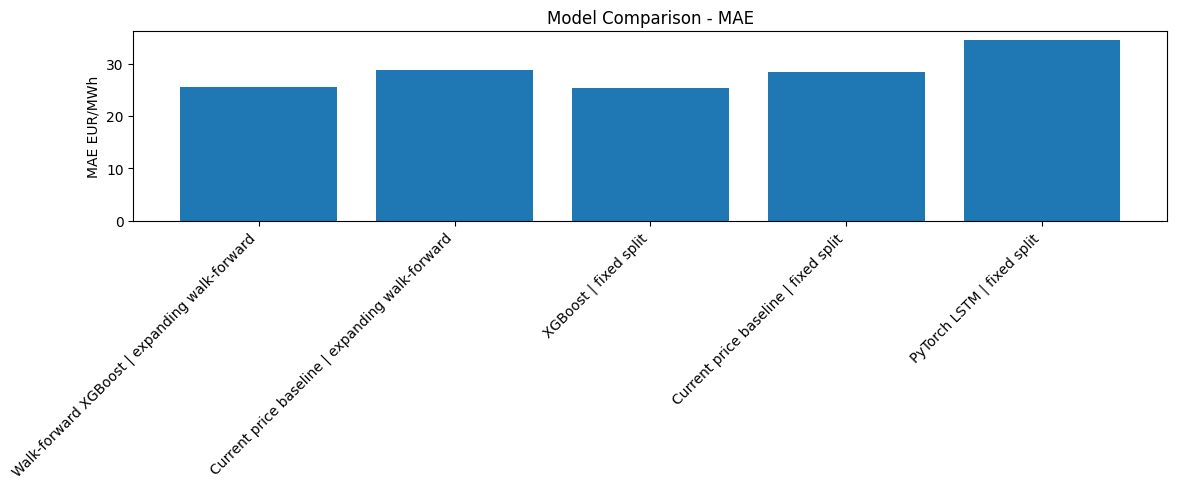

In [14]:
plt.figure(figsize=(12, 5))

plt.bar(
    final_comparison_sorted["model"] + " | " + final_comparison_sorted["validation"],
    final_comparison_sorted["MAE"]
)

plt.title("Model Comparison - MAE")
plt.ylabel("MAE EUR/MWh")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

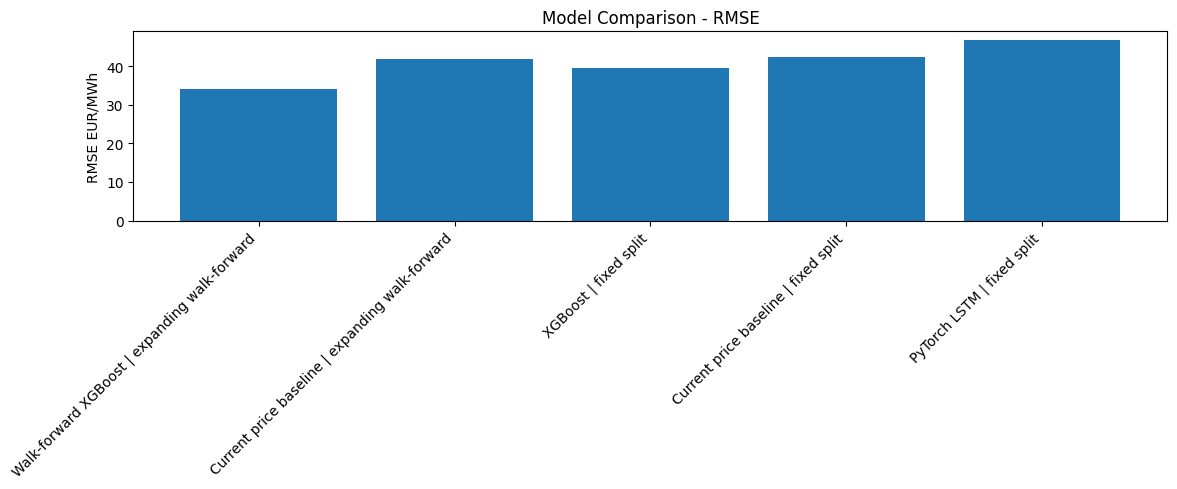

In [15]:
plt.figure(figsize=(12, 5))

plt.bar(
    final_comparison_sorted["model"] + " | " + final_comparison_sorted["validation"],
    final_comparison_sorted["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE EUR/MWh")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
final_comparison_sorted.to_csv(
    reports_dir / "final_model_comparison_DK2.csv",
    index=False
)

print("Saved:", reports_dir / "final_model_comparison_DK2.csv")

Saved: ..\reports\final_model_comparison_DK2.csv
